In [ ]:
import osmnx as ox

paris = ox.geocode_to_gdf(
    "Paris, France"
)

In [4]:
G = ox.graph_from_polygon(
    paris,
    network_type="bike",
    truncate_by_edge=True
)

nodes, edges = ox.graph_to_gdfs(G)

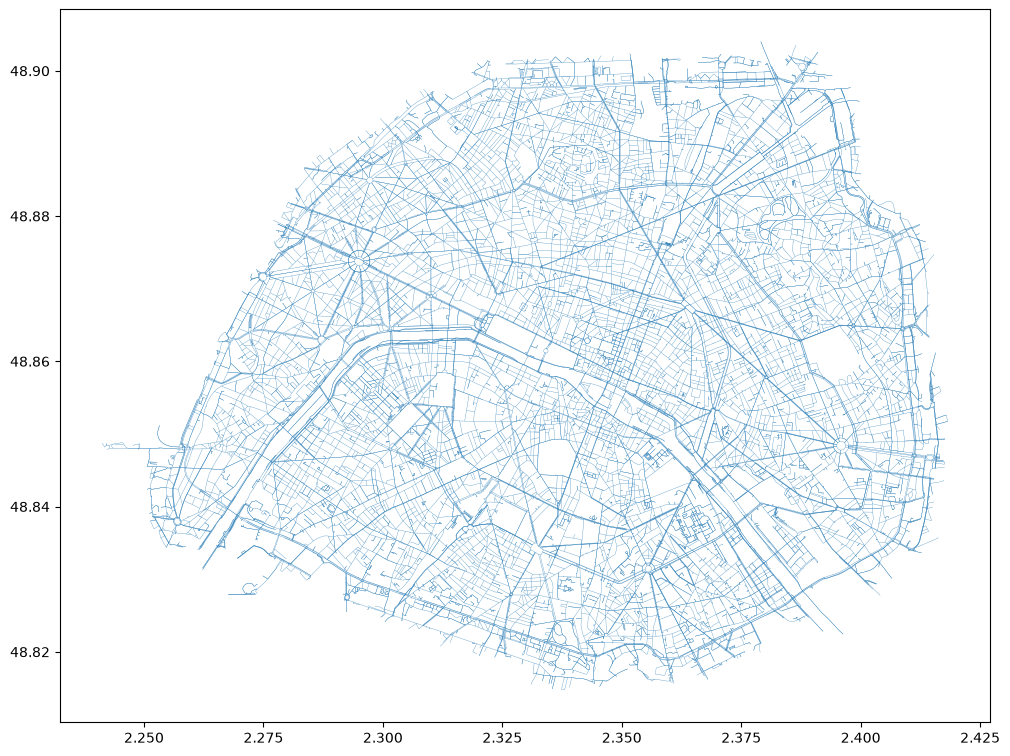

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

edges.plot(
    ax=ax,
    linewidth=0.2
)

plt.show()

In [6]:
import folium

m = folium.Map(
    location=[48.8566, 2.3522],
    zoom_start=12,
    tiles="CartoDB positron"
)

for geom in edges.geometry:
    folium.GeoJson(geom).add_to(m)

m.save("paris.html")

In [7]:
coverage_km = edges["length"].sum() / 1000
coverage_km

np.float64(2624.7034834935694)